# Análisis Exploratorio de Datos (EDA)
## Luces Nocturnas Satelitales y Machine Learning para la Predicción del IPM en la Región Caribe Colombiana (2018–2024)

**Autores:** Juan C. Aguirre & Camilo V. Escorcia — Universidad del Norte, Barranquilla  
**Fuente de datos:** DANE — Encuesta de Calidad de Vida (ECV), microdatos anuales 2018–2024  
**Prerequisito:** `01_Estructura.ipynb` — dataset limpio con tipos de datos corregidos  

---

## Contexto y Propósito del EDA

El Índice de Pobreza Multidimensional (IPM) es una medida compuesta que agrega privaciones en cinco dimensiones del bienestar: **Educación, Niñez y Juventud, Salud, Trabajo, y Vivienda y Servicios**. A diferencia de un indicador monetario, el IPM captura la coexistencia de múltiples carencias dentro de un mismo hogar, revelando patrones de vulnerabilidad que los promedios agregados tienden a enmascarar.

Este notebook responde tres preguntas analíticas centrales del proyecto:

1. **¿Cómo se distribuyen las privaciones por dimensión en la Región Caribe?** — Análisis univariado y departamental de cada indicador.
2. **¿Existe transmisión intergeneracional de la pobreza?** — Relación entre privaciones educativas y laborales con la condición de pobreza del hogar.
3. **¿Cuáles son las dimensiones con mayor poder explicativo sobre el IPM?** — Composición estructural de privaciones por departamento.

Los hallazgos de este notebook informan directamente las decisiones de feature engineering y selección de variables en el Notebook 3.

---

## Estructura de la sección

- 2.0 Configuración del entorno y carga del dataset  
- 2.1 EDA por dimensión del IPM  
- 2.3 La historia detrás de los datos: pobreza estructural y ciclos intergeneracionales  
- 2.4 Análisis de composición regional: privaciones por dimensión y departamento  


---
## 2.0 Configuración del Entorno y Carga del Dataset

Se reutiliza la configuración visual del Notebook 1 (paleta Viridis, constantes globales y funciones auxiliares) para garantizar consistencia en todo el proyecto. El dataset se carga y los tipos de datos se corrigen antes de cualquier análisis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# ── Configuración global de visualización ──────────────────────────────────
# Paleta Viridis como estándar del proyecto: accesible, perceptualmente uniforme
# y apta para impresión en escala de grises.
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'figure.facecolor': '#F7F9FC',
    'axes.facecolor': '#F7F9FC'
})

VIRIDIS      = plt.cm.viridis
COLOR_NO_PRIV = VIRIDIS(0.75)   # Azul-verde: estado favorable
COLOR_PRIV    = VIRIDIS(0.95)   # Amarillo: estado de privación / alerta
COVID_YEAR    = 2020            # Año de quiebre estructural — pandemia COVID-19

print("Entorno configurado.")


Entorno configurado.


In [2]:
# Carga del dataset integrado 2018–2024 (Región Caribe)
df = pd.read_csv(
    r"../data/IPM_2018_2024_CLEAN_CARIBE.csv",
    sep=';'
)

# ── Corrección de tipos heredados del formato DANE ─────────────────────────
# Los campos fex_c, fexp e ipm llegan como texto con comas decimales.
# Se normalizan a float64 antes de cualquier operación numérica.
def limpiar_numerico(serie):
    return pd.to_numeric(
        serie.astype(str)
             .str.replace('"', '', regex=False)
             .str.replace(',', '.', regex=False)
             .str.strip(),
        errors='coerce'
    )

for col in ['fex_c', 'fexp', 'ipm']:
    df[col] = limpiar_numerico(df[col])

print(f"Dataset cargado: {df.shape[0]:,} hogares | {df.shape[1]} variables")
print(f"Periodo: {df['año'].min()} – {df['año'].max()} | "
      f"Departamentos: {df['departamento_nombre'].nunique()}")


Dataset cargado: 135,835 hogares | 28 variables
Periodo: 2018 – 2024 | Departamentos: 7


In [3]:
# Funciones de visualización reutilizables — estandarizadas con paleta Viridis

def plot_privacion(df, variable, titulo):
    """
    Distribución binaria de una variable de privación del IPM.
    Muestra frecuencia absoluta y proporción relativa para los estados
    No Privación (0) y Privación (1).
    """
    conteo = df[variable].value_counts().sort_index()
    conteo.index = ['No privación', 'Privación']
    proporcion = conteo / conteo.sum()

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(conteo.index, conteo.values,
                  color=[COLOR_NO_PRIV, COLOR_PRIV], edgecolor='white', linewidth=0.8)

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Estado de Privación', fontsize=11)
    ax.set_ylabel('Frecuencia Absoluta', fontsize=11)

    for i, bar in enumerate(bars):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h,
                f"{int(h):,}", ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.text(bar.get_x() + bar.get_width() / 2, h / 2,
                f"{proporcion.iloc[i]:.1%}", ha='center', va='center',
                fontsize=10, color='white', fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.25, boxstyle='round,pad=0.3', edgecolor='none'))
    plt.tight_layout()
    plt.show()


def plot_evolucion_y_departamento(df, variable, titulo):
    """
    Vista dual para variables indicadoras del IPM:
      - Panel izquierdo: proporción de privación por departamento (barras apiladas).
      - Panel derecho: evolución temporal con marcador de quiebre COVID-19 (2020).
    Permite identificar heterogeneidad territorial y trayectorias temporales
    en una sola figura.
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Panel izquierdo — comparativa departamental
    tabla = pd.crosstab(df['departamento_nombre'], df[variable], normalize='index')
    tabla.columns = ['No privación', 'Privación']
    tabla = tabla.sort_values('Privación', ascending=True)
    tabla.plot(kind='barh', stacked=True, ax=axes[0],
               color=[COLOR_NO_PRIV, COLOR_PRIV], edgecolor='white')
    axes[0].set_title(f"{titulo} — Por Departamento", fontsize=13, fontweight='bold', pad=10)
    axes[0].set_xlabel('Proporción', fontsize=11)
    axes[0].set_ylabel('Departamento', fontsize=11)
    for container in axes[0].containers:
        axes[0].bar_label(container,
                          labels=[f"{v:.1%}" for v in container.datavalues],
                          label_type='center', fontsize=8,
                          color='white', fontweight='bold')

    # Panel derecho — evolución temporal
    evolucion = df.groupby(['año', 'departamento_nombre'])[variable].mean().reset_index()
    departamentos = evolucion['departamento_nombre'].unique()
    palette = [VIRIDIS(i / max(len(departamentos) - 1, 1)) for i in range(len(departamentos))]

    for dep, color in zip(departamentos, palette):
        subset = evolucion[evolucion['departamento_nombre'] == dep]
        axes[1].plot(subset['año'], subset[variable],
                     marker='o', linewidth=2, label=dep, color=color)

    axes[1].axvline(x=COVID_YEAR, linestyle='dotted', linewidth=2,
                    color='crimson', alpha=0.8, label='COVID-19 (2020)')
    axes[1].set_title(f"Evolución Temporal — {titulo}", fontsize=13, fontweight='bold', pad=10)
    axes[1].set_xlabel('Año', fontsize=11)
    axes[1].set_ylabel('Proporción de Privación', fontsize=11)
    axes[1].legend(title='Departamento', bbox_to_anchor=(1.05, 1),
                   loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


---
## 2.1 EDA por Dimensión del IPM

Cada variable indicadora se analiza en dos niveles:

- **Nivel agregado:** distribución global entre privación y no privación en el periodo completo.
- **Nivel territorial y temporal:** comparativa por departamento y evolución año a año, con énfasis en el impacto de la pandemia COVID-19 (2020) como choque estructural documentado.

Las privaciones cubiertas en este análisis corresponden a las dimensiones de **Educación, Niñez y Juventud, Salud y Trabajo**. La dimensión de Vivienda y Servicios se aborda en la sección de composición regional (Sección 4).


### 2.1.1 Dimensión: Educación

La dimensión de Educación concentra cuatro indicadores: alfabetismo, logro educativo, inasistencia escolar y rezago escolar. Los dos primeros miden el capital educativo acumulado de los adultos del hogar, mientras que los dos últimos capturan la situación actual de los niños y adolescentes. Su análisis conjunto permite identificar la transmisión intergeneracional de las carencias educativas, que se profundiza en la Sección 3.

#### Alfabetismo

Toma valor `1` si al menos un miembro del hogar mayor de 15 años no sabe leer ni escribir. Es el umbral más básico de inclusión educativa y actúa como barrera de entrada al mercado laboral formal.


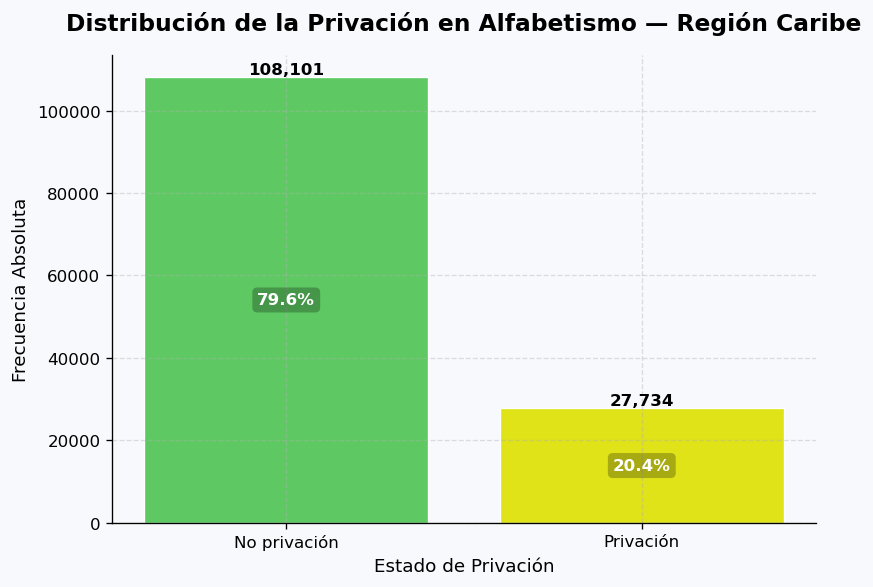

In [4]:
# Distribución global de alfabetismo en la Región Caribe (2018–2024)
plot_privacion(df, 'alfabetismo', 'Distribución de la Privación en Alfabetismo — Región Caribe')


> El 20.4 % de los hogares analizados presenta privación en alfabetismo — aproximadamente 1 de cada 5 hogares en la Región Caribe tiene al menos un adulto que no sabe leer ni escribir. Aunque esta cifra es menor que la de logro educativo (56 %), su impacto sobre la empleabilidad y el acceso a servicios formales es desproporcionadamente alto.


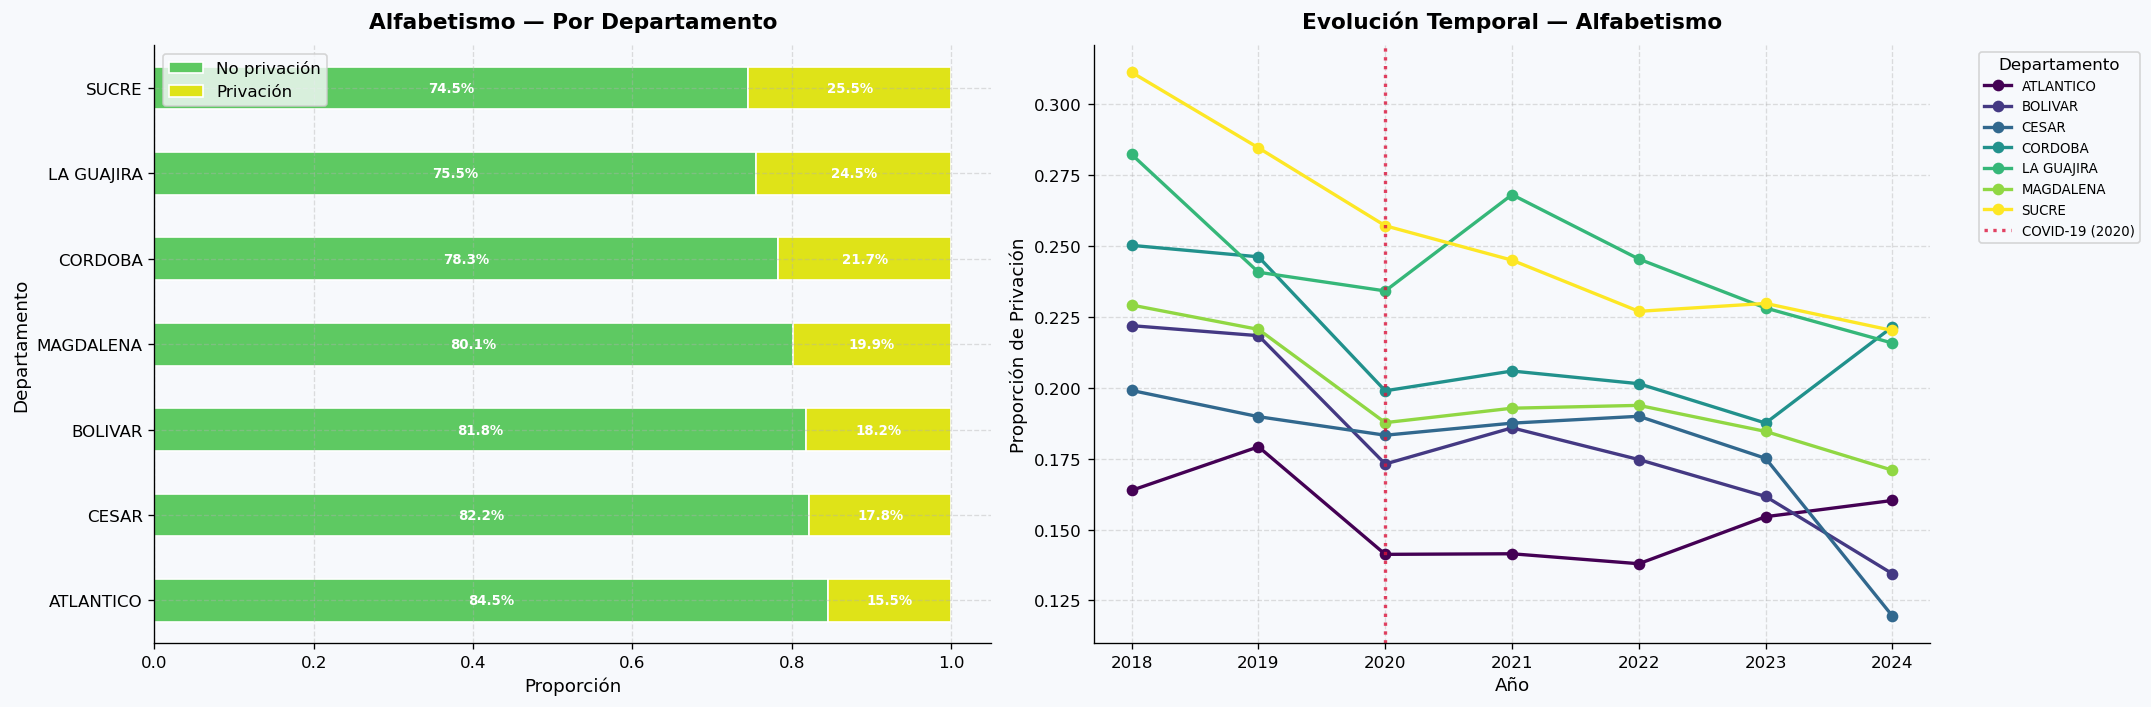

In [5]:
# Heterogeneidad departamental y evolución temporal del alfabetismo
# La línea punteada roja marca el año 2020 como quiebre por pandemia COVID-19.
# Una caída técnica en las curvas durante ese año coincide con la Circular 003-2020
# del Atlántico, que flexibilizó los criterios de evaluación y promoción escolar.
plot_evolucion_y_departamento(df, 'alfabetismo', 'Alfabetismo')


> La reducción observada en varios indicadores educativos durante 2020 no refleja necesariamente una mejora real. La Circular No. 003-2020 instruyó a las instituciones educativas a implementar evaluación formativa no sancionatoria y a no reprobar estudiantes por inasistencia durante la emergencia sanitaria, lo que generó un artefacto estadístico en los indicadores de ese año.

#### Logro Educativo

Toma valor `1` si el promedio de años de educación de los miembros del hogar mayores de 15 años es inferior a 9 años (umbral: aprobación del noveno grado). Este indicador mide el capital humano acumulado de los adultos del hogar y tiene una alta correlación con el acceso al empleo formal.


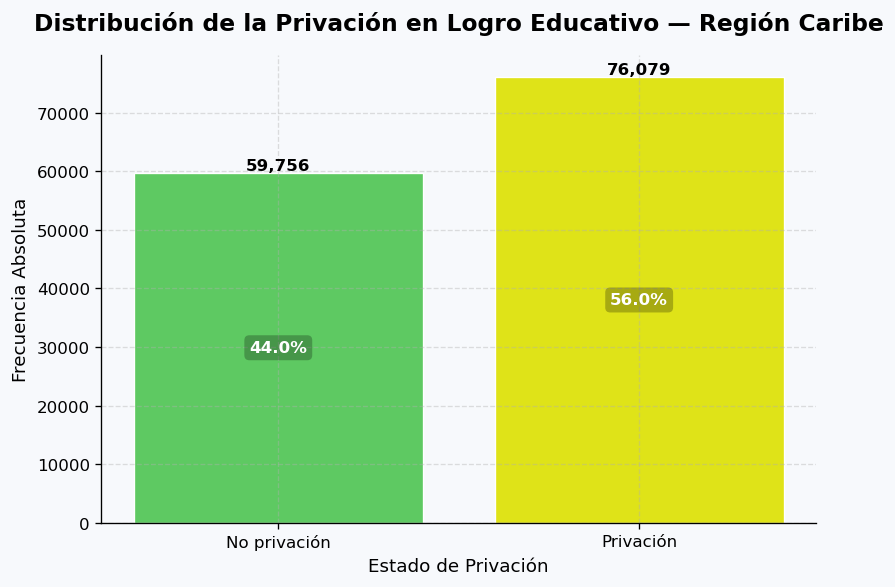

In [6]:
# Distribución global del logro educativo
# Esta variable registra la privación más extendida de toda la dimensión Educación:
# más de la mitad de los hogares en la región no alcanzan el umbral mínimo educativo.
plot_privacion(df, 'logro_educativo', 'Distribución de la Privación en Logro Educativo — Región Caribe')


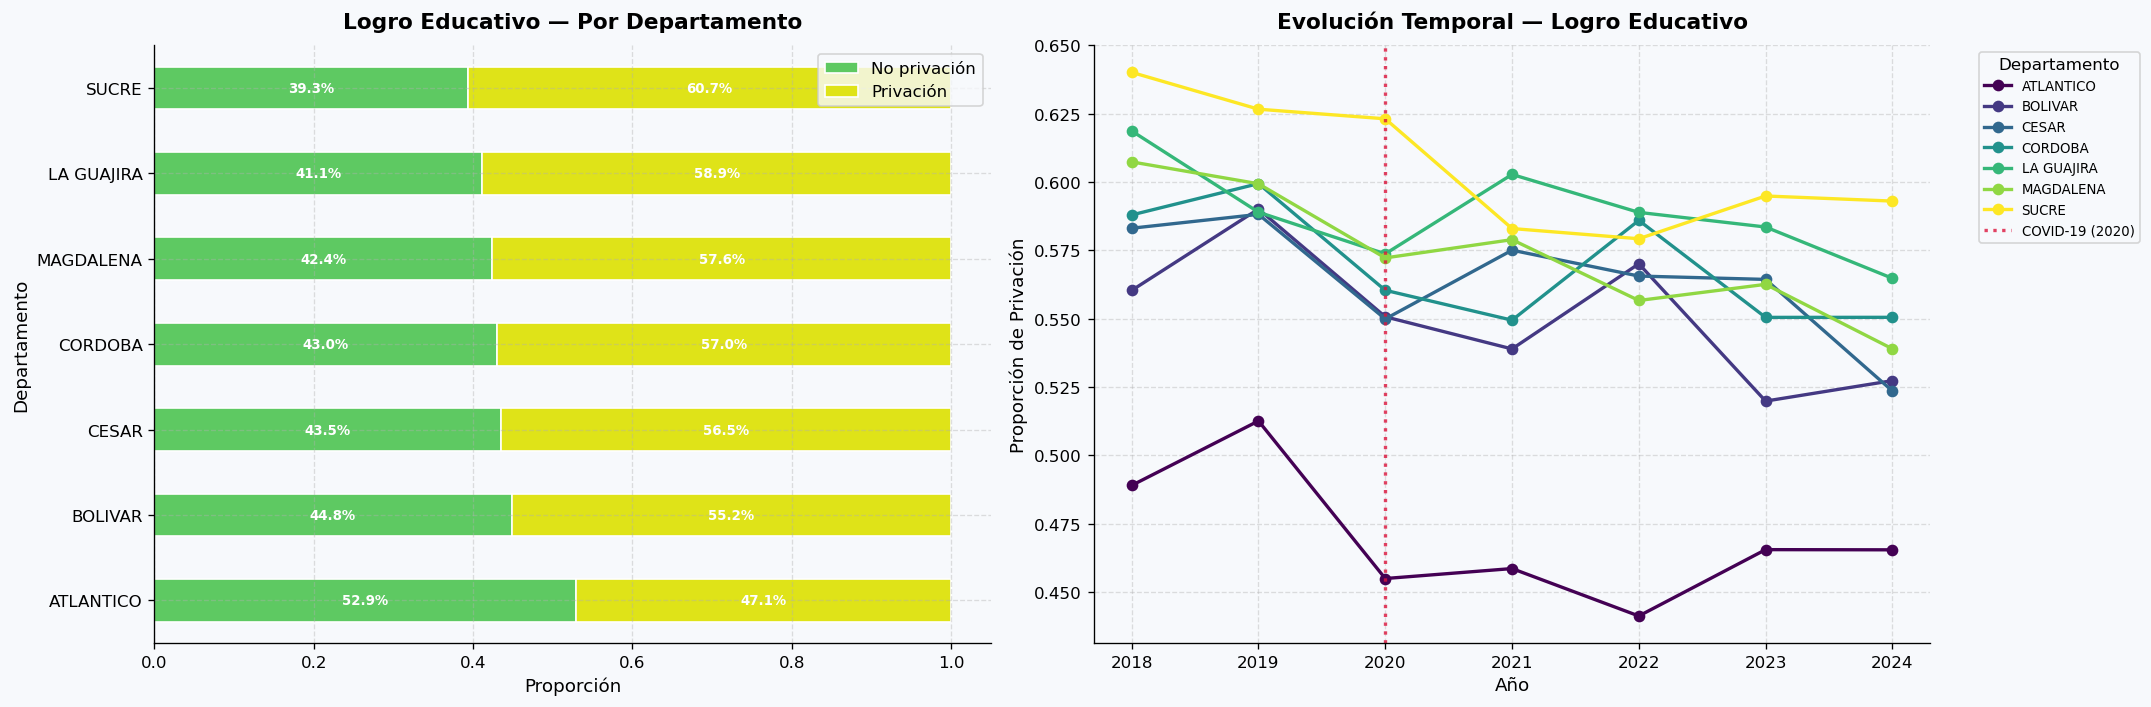

In [7]:
# Evolución departamental del logro educativo
# Se espera que departamentos con mayor inversión histórica en educación
# (como Atlántico) muestren tendencias decrecientes más pronunciadas.
plot_evolucion_y_departamento(df, 'logro_educativo', 'Logro Educativo')


> Con un 56 % de privación, el logro educativo es el indicador más crítico de la dimensión Educación. Esta cifra significa que en más de la mitad de los hogares de la Región Caribe, los adultos no completaron la educación básica secundaria. La brecha entre alfabetismo (20.4 %) y logro educativo (56 %) revela un fenómeno importante: muchos adultos saben leer y escribir, pero no lograron mantenerse en el sistema educativo más allá de los primeros años.

### 2.1.2 Dimensión: Niñez y Juventud

Esta dimensión incluye indicadores que capturan la situación actual de los niños y adolescentes del hogar. Son particularmente relevantes porque representan tanto el efecto de las condiciones de pobreza sobre la generación presente como el riesgo de reproducción de esas condiciones en la siguiente generación.

#### Inasistencia Escolar

Toma valor `1` si al menos un niño del hogar entre 6 y 16 años no asiste a una institución educativa.


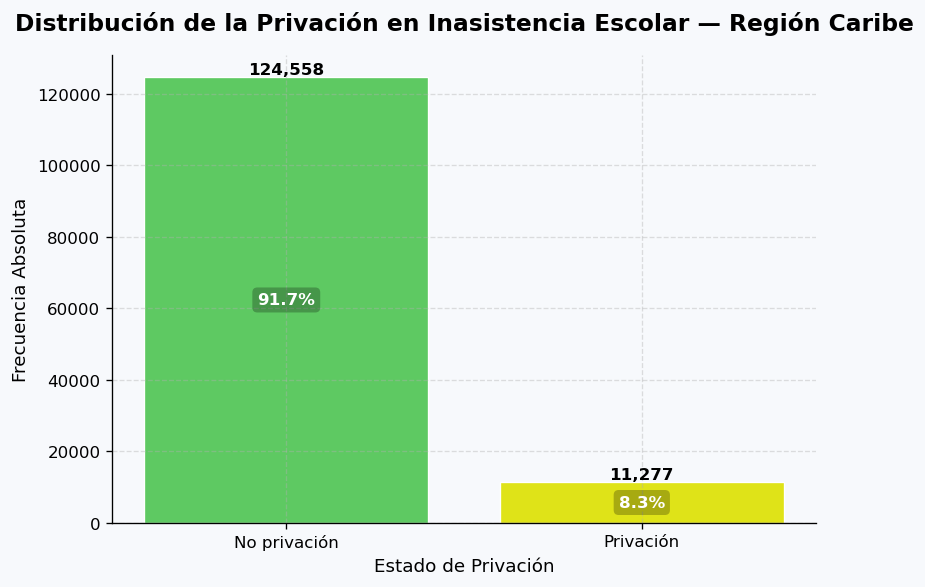

In [8]:
plot_privacion(df, 'inasistencia_escolar', 'Distribución de la Privación en Inasistencia Escolar — Región Caribe')


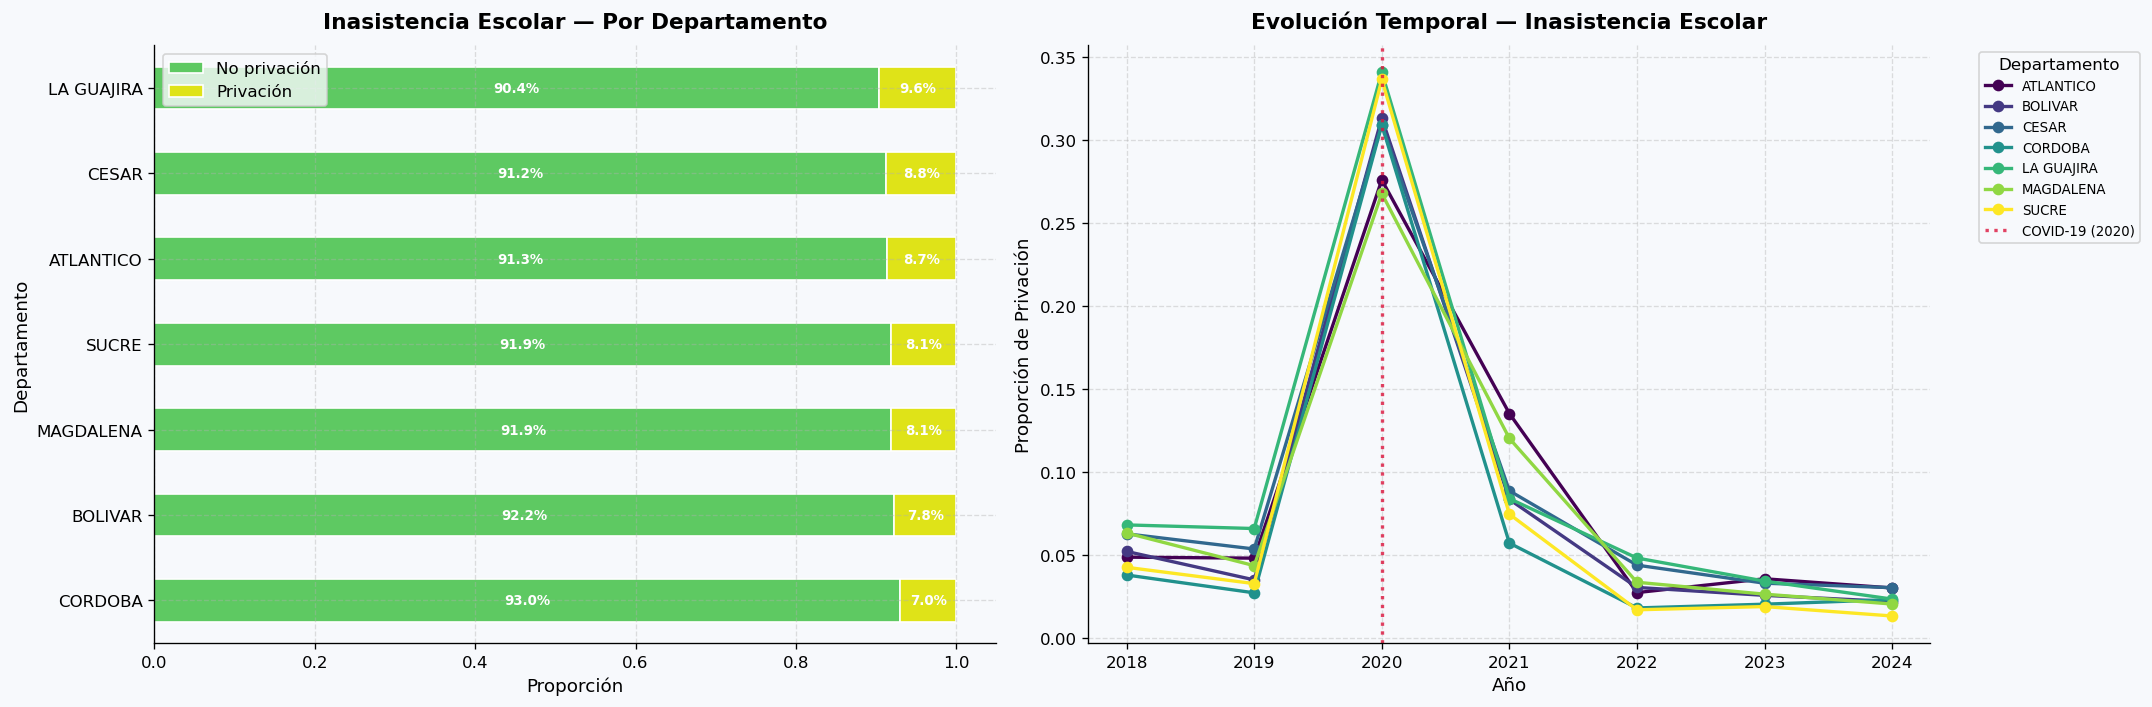

In [9]:
# La línea COVID-19 (2020) es particularmente relevante aquí:
# La inasistencia escolar registró un pico dramático durante la pandemia
# en departamentos como La Guajira y Sucre, alcanzando niveles cercanos al 35%.
# La recuperación posterior a 2021 fue generalizada pero heterogénea entre departamentos.
plot_evolucion_y_departamento(df, 'inasistencia_escolar', 'Inasistencia Escolar')


>  Con una privación del 8.3 % en el periodo agregado, la inasistencia escolar tiene el nivel más bajo de las variables educativas. Sin embargo, su comportamiento temporal revela la mayor sensibilidad al choque de la pandemia: La Guajira y Sucre superaron el 30 % de privación durante 2020. Para 2024, todos los departamentos habían estabilizado tasas por debajo del 5 %, evidenciando una recuperación sostenida del sistema educativo regional.

### 2.1.3 Dimensión: Salud

La dimensión de Salud mide tanto el acceso formal al sistema de aseguramiento como las barreras efectivas de uso cuando surge una necesidad. Son indicadores complementarios: el primero captura cobertura y el segundo, acceso real.

#### Aseguramiento en Salud

Toma valor `1` si al menos un miembro mayor de 5 años no está afiliado al sistema de salud (SGSSS).


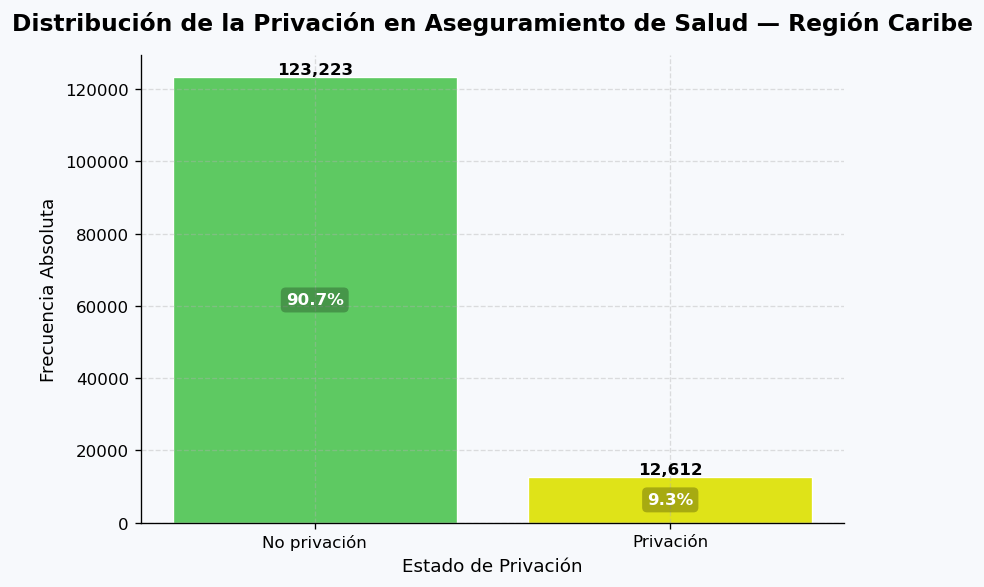

In [10]:
plot_privacion(df, 'aseguramiento_salud', 'Distribución de la Privación en Aseguramiento de Salud — Región Caribe')


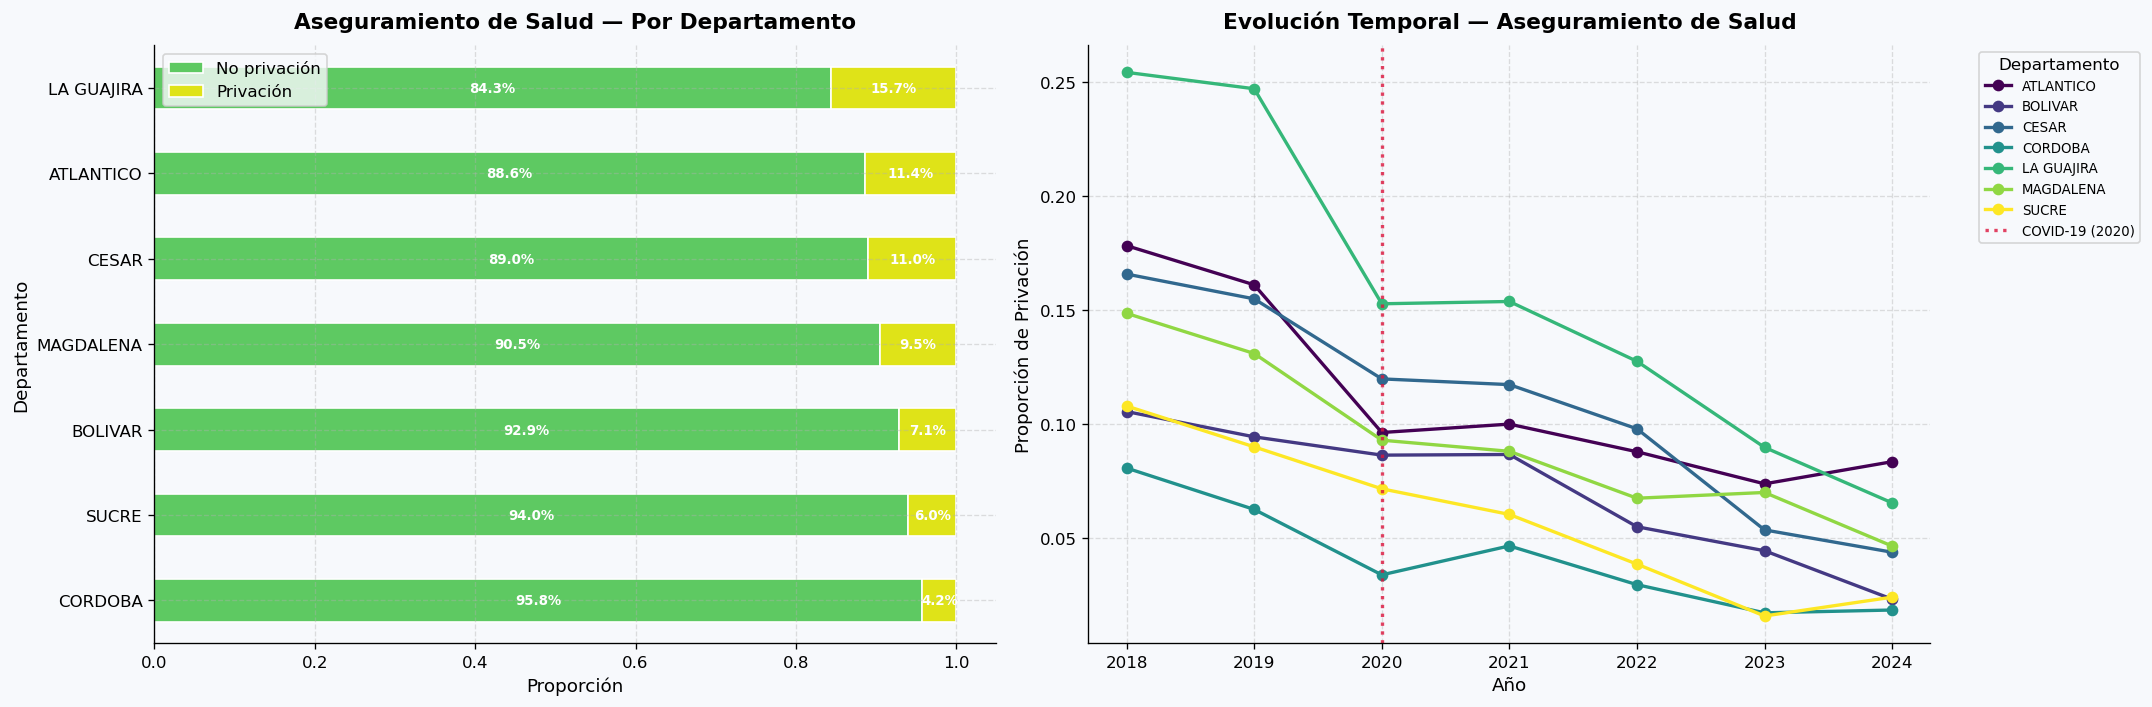

In [11]:
# La pandemia tuvo un efecto notable en esta variable:
# el aseguramiento aumentó durante 2020 en la mayoría de departamentos,
# posiblemente debido a campañas de afiliación para garantizar acceso
# a servicios durante la emergencia sanitaria.
plot_evolucion_y_departamento(df, 'aseguramiento_salud', 'Aseguramiento de Salud')


>  El aseguramiento es uno de los indicadores más favorables de la región, con solo 9.3 % de privación. La pandemia produjo aquí un efecto opuesto al de otros indicadores: la cobertura mejoró, probablemente por afiliaciones de emergencia. La Guajira (15.7 % de privación) y Córdoba (4.2 %) marcan los extremos departamentales.

#### Barreras de Acceso a la Salud

Toma valor `1` si algún miembro del hogar con una necesidad de salud en los últimos 30 días no pudo ser atendido por un profesional o institución. Mide no la cobertura formal, sino el acceso efectivo al servicio.


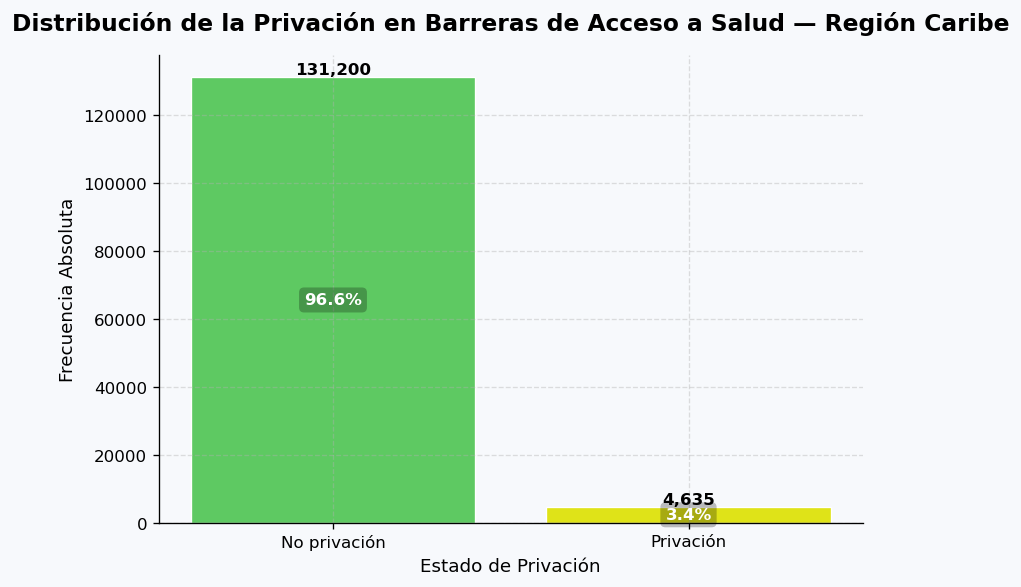

In [12]:
plot_privacion(df, 'barreras_acceso_salud', 'Distribución de la Privación en Barreras de Acceso a Salud — Región Caribe')


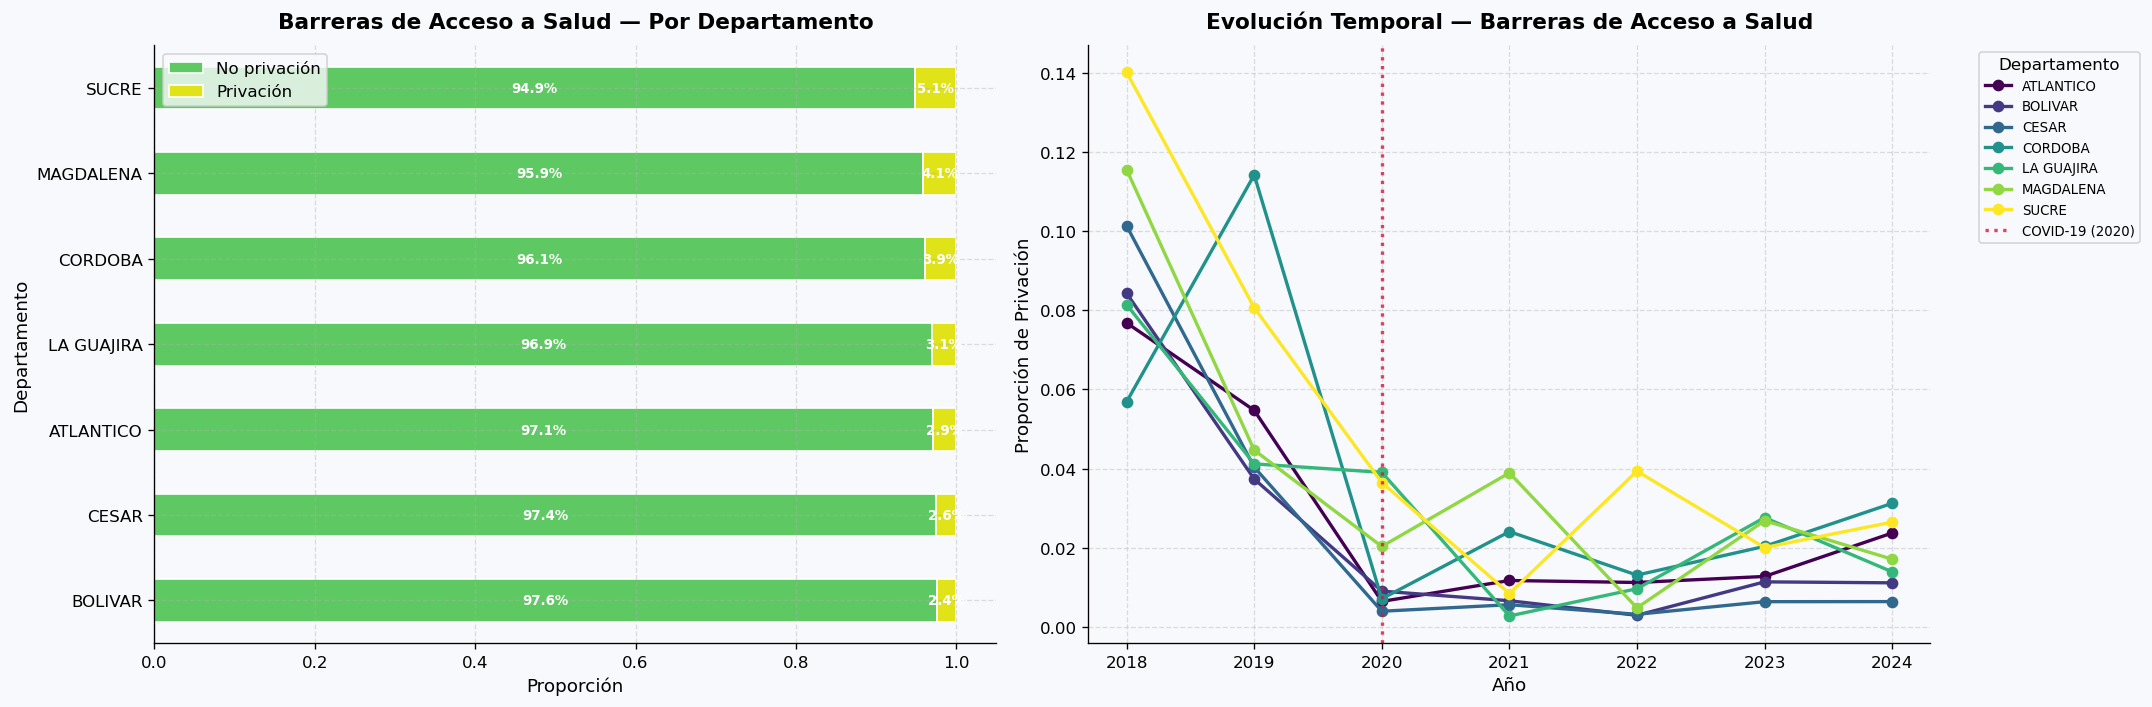

In [13]:
plot_evolucion_y_departamento(df, 'barreras_acceso_salud', 'Barreras de Acceso a Salud')


>  Con solo 3.4 % de privación, las barreras de acceso a salud representan el indicador más bajo de todo el estudio. La caída durante 2020 es contraintuitiva frente a las restricciones de movilidad de la pandemia, pero puede explicarse por la reactivación prioritaria de servicios básicos de salud y la mayor sensibilización de la población para buscar atención. Bolívar (2.4 %), Cesar (2.6 %) y Atlántico (2.9 %) lideran en acceso efectivo.

### 2.1.4 Dimensión: Trabajo

La dimensión de Trabajo contiene los indicadores con mayor poder predictivo sobre la condición de pobreza en la región. El mercado laboral caribeño se caracteriza por una informalidad estructural que se manifiesta con alta intensidad y relativa homogeneidad entre departamentos.

#### Empleo Formal

Toma valor `1` si al menos un miembro ocupado del hogar no tiene afiliación a pensiones. Es el principal proxy de informalidad laboral en los microdatos del DANE.


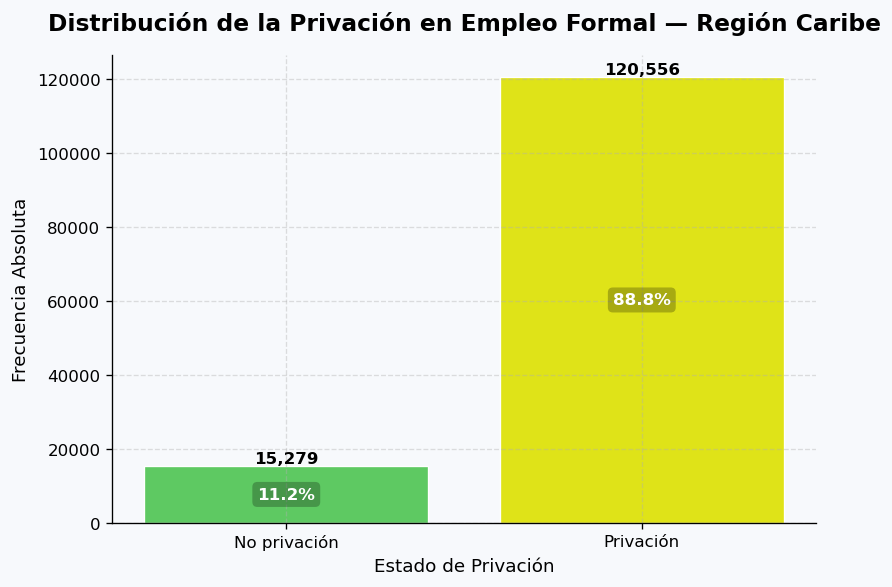

In [14]:
plot_privacion(df, 'empleo_formal', 'Distribución de la Privación en Empleo Formal — Región Caribe')


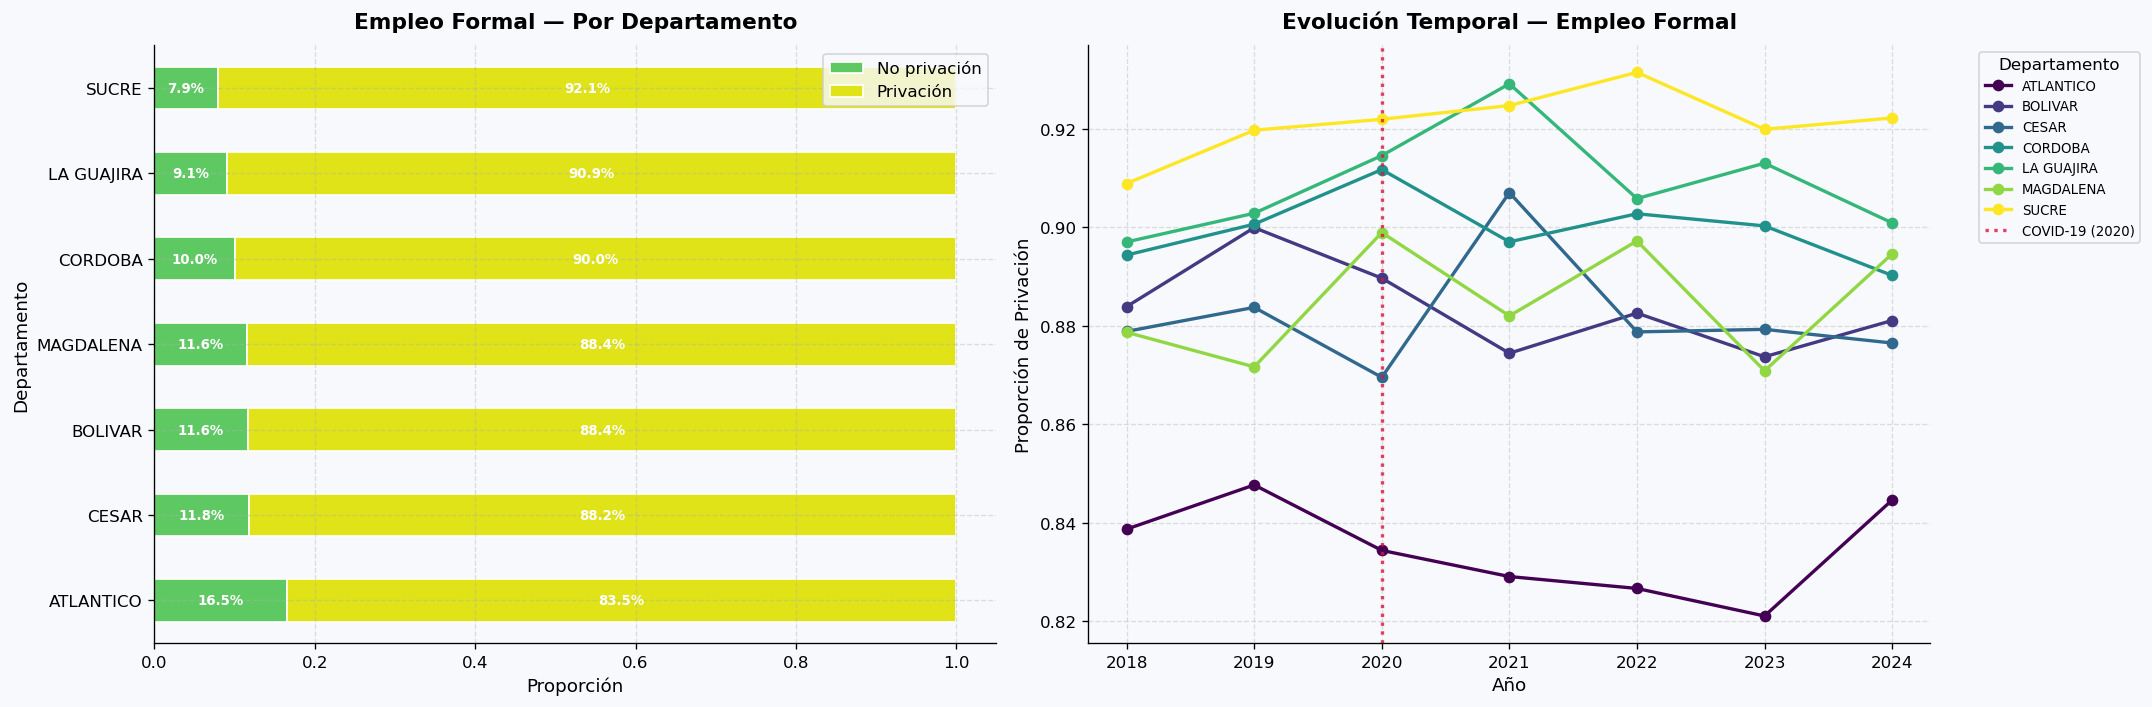

In [15]:
# El empleo formal es la variable con mayor privación de todo el dataset (88.8%).
# A diferencia de los indicadores de salud y educación, la pandemia no produjo
# mejoras aquí: en departamentos como Córdoba y La Guajira, la informalidad
# aumentó levemente durante 2020 por la destrucción de empleo formal.
plot_evolucion_y_departamento(df, 'empleo_formal', 'Empleo Formal')


>  El empleo formal registra la privación más alta del estudio — 88.8 % de los hogares. La brecha entre departamentos es mínima: todos superan el 83 % de privación, lo que confirma que la informalidad laboral no es una característica puntual de algún departamento rezagado, sino un rasgo **estructural y homogéneo** de la economía caribeña colombiana. Atlántico (83.5 %) es el mejor posicionado, pero su cifra sigue siendo alarmantemente alta.

#### Desempleo de Larga Duración

Toma valor `1` si al menos un miembro de la PEA ha estado desempleado por más de 12 meses consecutivos.


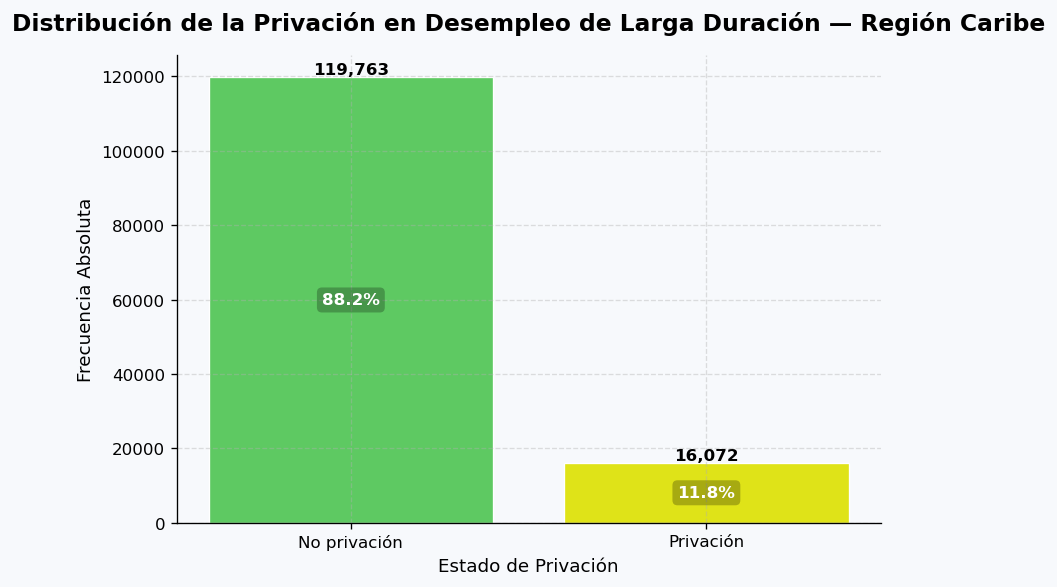

In [16]:
plot_privacion(df, 'desempleo_larga_duracion', 'Distribución de la Privación en Desempleo de Larga Duración — Región Caribe')


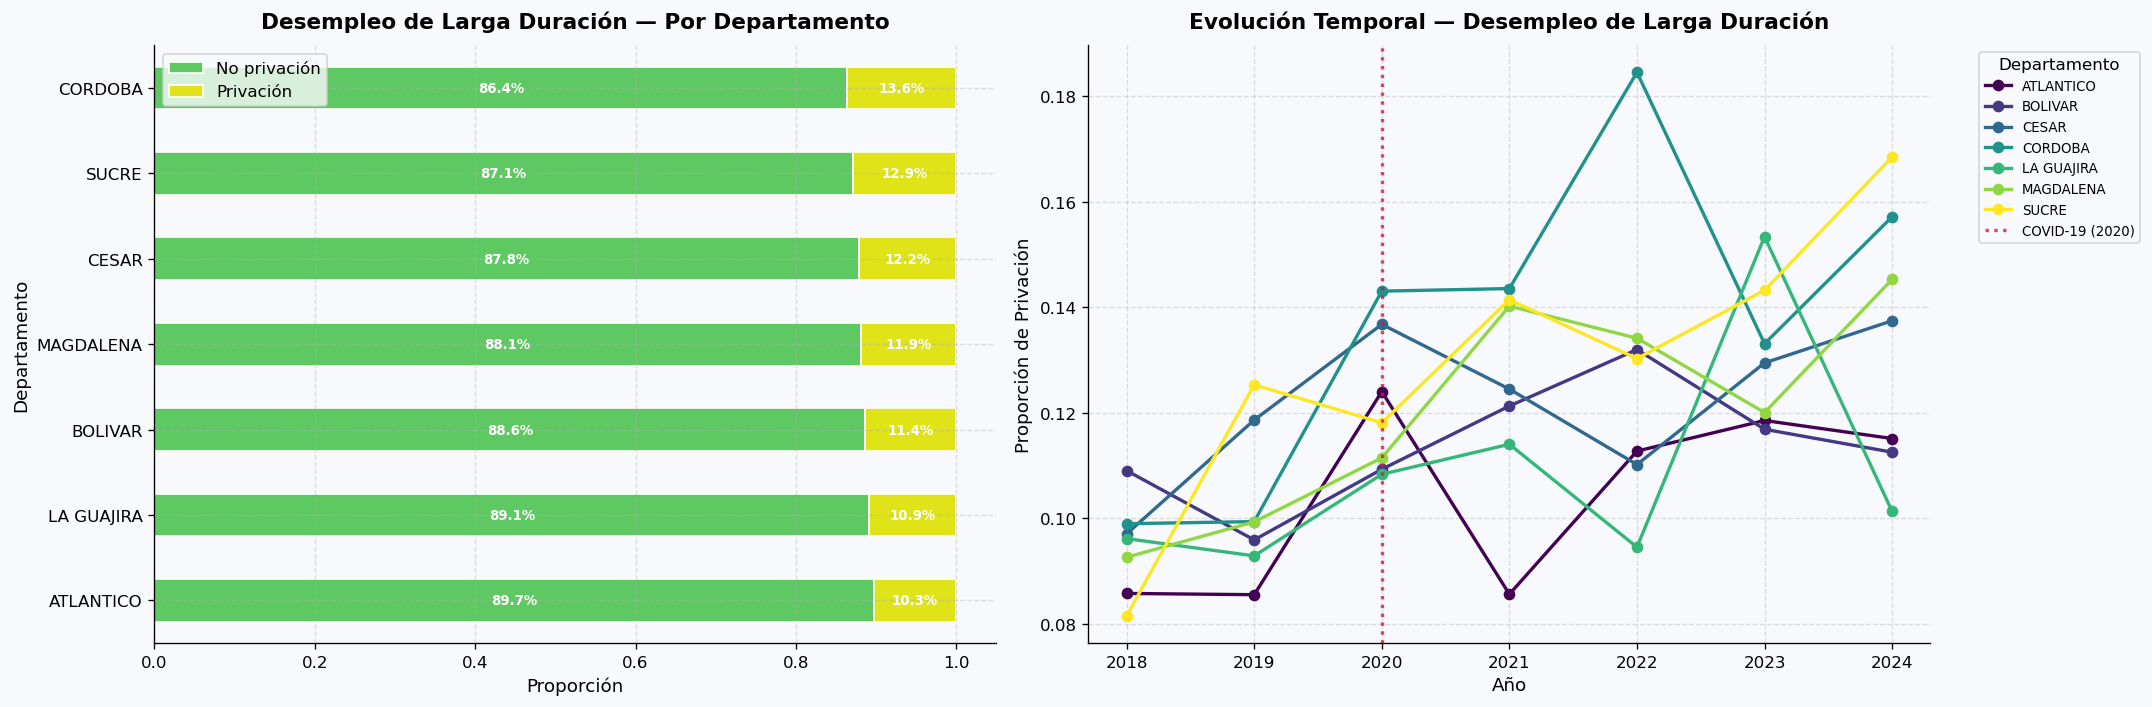

In [17]:
plot_evolucion_y_departamento(df, 'desempleo_larga_duracion', 'Desempleo de Larga Duración')


>  El desempleo de larga duración (11.8 %) contrasta de forma llamativa con el empleo formal (88.8 %). La población de la Región Caribe no permanece desempleada por periodos extendidos, pero el trabajo que consigue es mayoritariamente informal. Esto sugiere que la barrera no es la falta de trabajo, sino la calidad y las condiciones contractuales del trabajo disponible. Córdoba (13.6 %) y Sucre (12.9 %) muestran las mayores dificultades para la reinserción laboral post-pandemia.


---
## 2.2 La Historia Detrás de los Datos

El análisis por variable individual revela patrones importantes, pero la comprensión profunda de la pobreza multidimensional requiere examinar las **relaciones entre privaciones** y su efecto conjunto sobre la condición de pobreza del hogar. Esta sección construye una narrativa causal a partir de los datos, articulando tres mecanismos centrales identificados en la literatura y validados empíricamente con los microdatos del DANE.


### 2.2.1 La Pobreza es Multidimensional y Estructural

Para ilustrar cómo diferentes privaciones se asocian con la condición de pobreza, se compara la distribución de hogares pobres y no pobres según su estado en cinco privaciones clave — seleccionadas por su relevancia teórica y su varianza observada en el EDA previo.

El gráfico muestra, para cada variable, qué proporción de hogares **con** y **sin** esa privación terminan siendo clasificados como pobres (IPM ≥ 33 %).


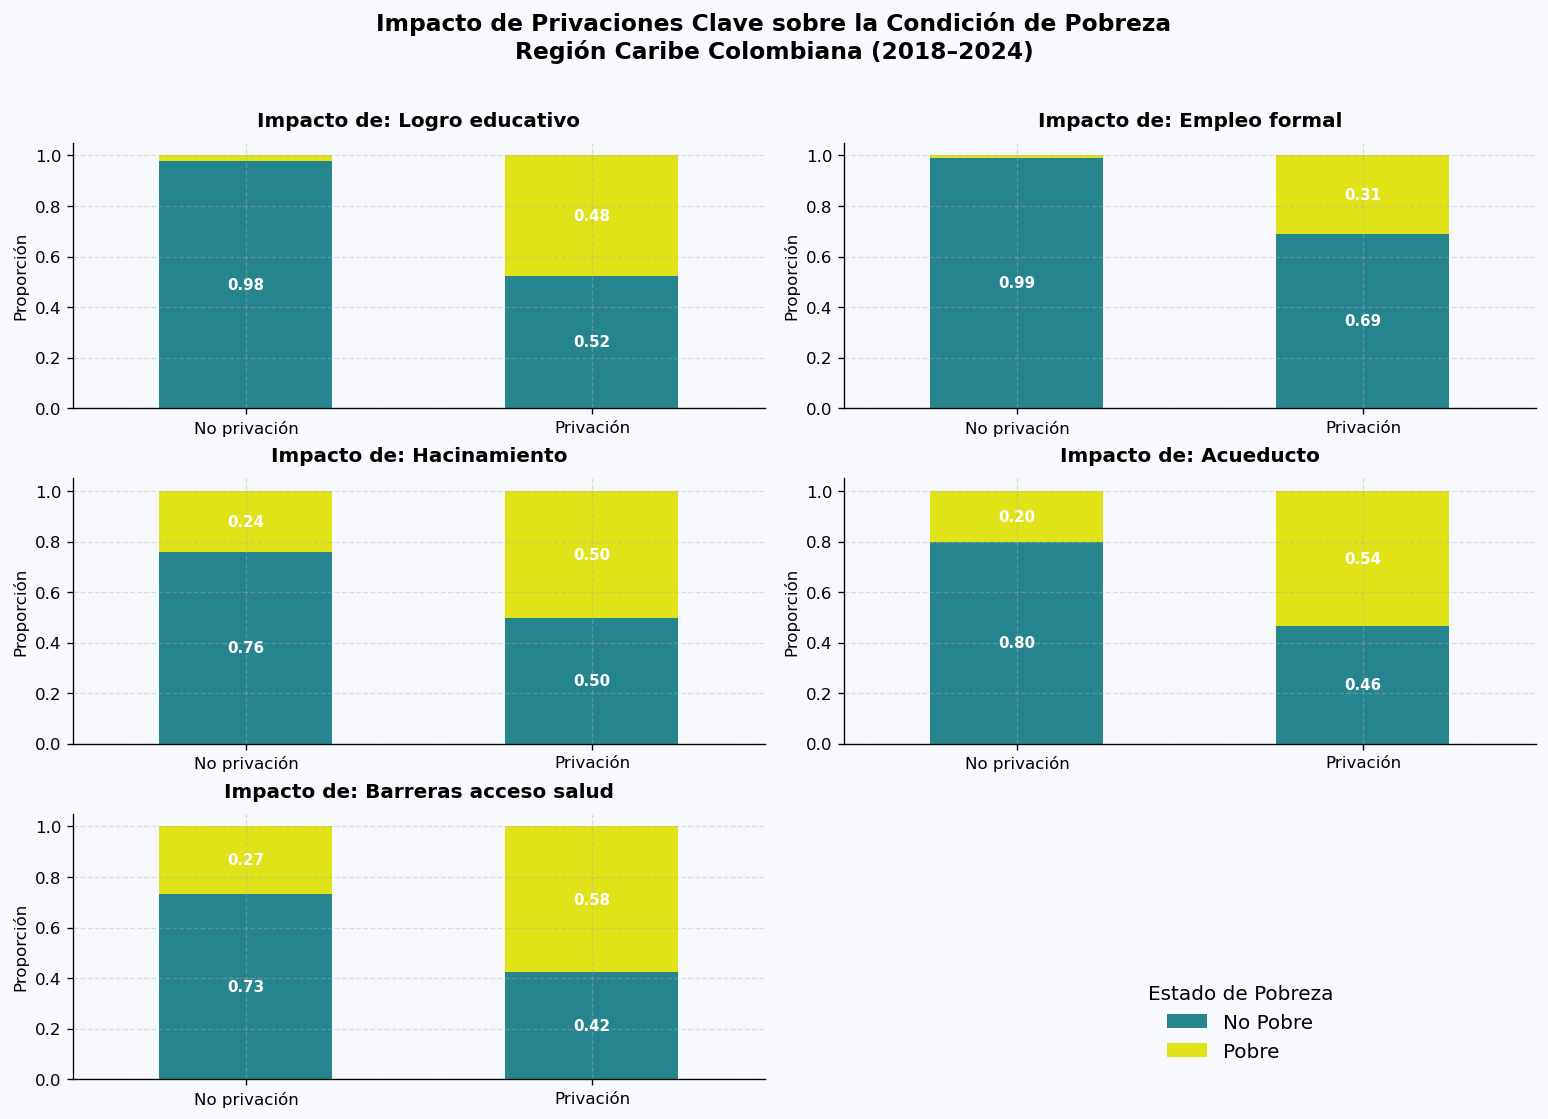

In [18]:
# Privaciones seleccionadas por relevancia teórica y poder discriminativo:
# logro_educativo y empleo_formal son las de mayor prevalencia;
# hacinamiento, acueducto y barreras_acceso_salud representan dimensiones de vivienda y salud.
variables_impacto = [
    'logro_educativo',
    'empleo_formal',
    'hacinamiento',
    'acueducto',
    'barreras_acceso_salud'
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 10))
axes = axes.flatten()

# Dos colores de la escala Viridis: verde-azul (No Pobre) y amarillo (Pobre)
colores_estado = [VIRIDIS(0.45), VIRIDIS(0.95)]

for i, var in enumerate(variables_impacto):
    # Tabla cruzada: proporción de pobres/no pobres para cada estado de privación
    tabla = pd.crosstab(df[var], df['pobre'], normalize='index')
    tabla.plot(
        kind='bar', stacked=True, ax=axes[i],
        color=colores_estado, width=0.5,
        legend=False, edgecolor='none'
    )
    titulo_limpio = var.replace('_', ' ').capitalize()
    axes[i].set_title(f"Impacto de: {titulo_limpio}",
                      fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel('Proporción', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['No privación', 'Privación'], rotation=0, fontsize=10)

    # Etiquetas de proporción dentro de cada segmento de barra
    for container in axes[i].containers:
        for bar in container:
            h = bar.get_height()
            if h > 0.05:
                axes[i].text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + h / 2,
                    f"{h:.2f}", ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold'
                )

# Leyenda global compartida
handles, _ = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No Pobre', 'Pobre'],
           loc='lower right', bbox_to_anchor=(0.87, 0.12),
           frameon=False, fontsize=12,
           title='Estado de Pobreza', title_fontsize=12)

fig.suptitle('Impacto de Privaciones Clave sobre la Condición de Pobreza\n'
             'Región Caribe Colombiana (2018–2024)',
             fontsize=14, fontweight='bold', y=1.01)

fig.delaxes(axes[5])  # Eliminar el sexto panel vacío
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()


>  En todas las variables analizadas, la presencia de privación se asocia con una proporción significativamente mayor de hogares pobres. El logro educativo y el empleo formal son los predictores más fuertes: la privación en estas variables prácticamente duplica o triplica la probabilidad de pobreza respecto a hogares sin esa carencia. Este resultado motiva su inclusión prioritaria como features en el modelamiento del Notebook 3.


### 2.2.2 ¿La Pobreza se Hereda? Privaciones en Niñez y Reproducción de la Vulnerabilidad

La literatura sobre movilidad social (Heckman, 2006; Becker & Tomes, 1986; OCDE, 2018) propone que las privaciones tempranas en la infancia tienen efectos persistentes sobre las oportunidades de vida. Según la OCDE (2018), una familia en el 10 % más pobre de Colombia requeriría aproximadamente **11 generaciones** para alcanzar el ingreso promedio nacional, lo que evidencia la rigidez de la movilidad social en el contexto colombiano.

Esta sección examina empíricamente si los datos del IPM respaldan esta hipótesis, evaluando cómo las privaciones en niñez y juventud se asocian con la condición de pobreza actual del hogar.


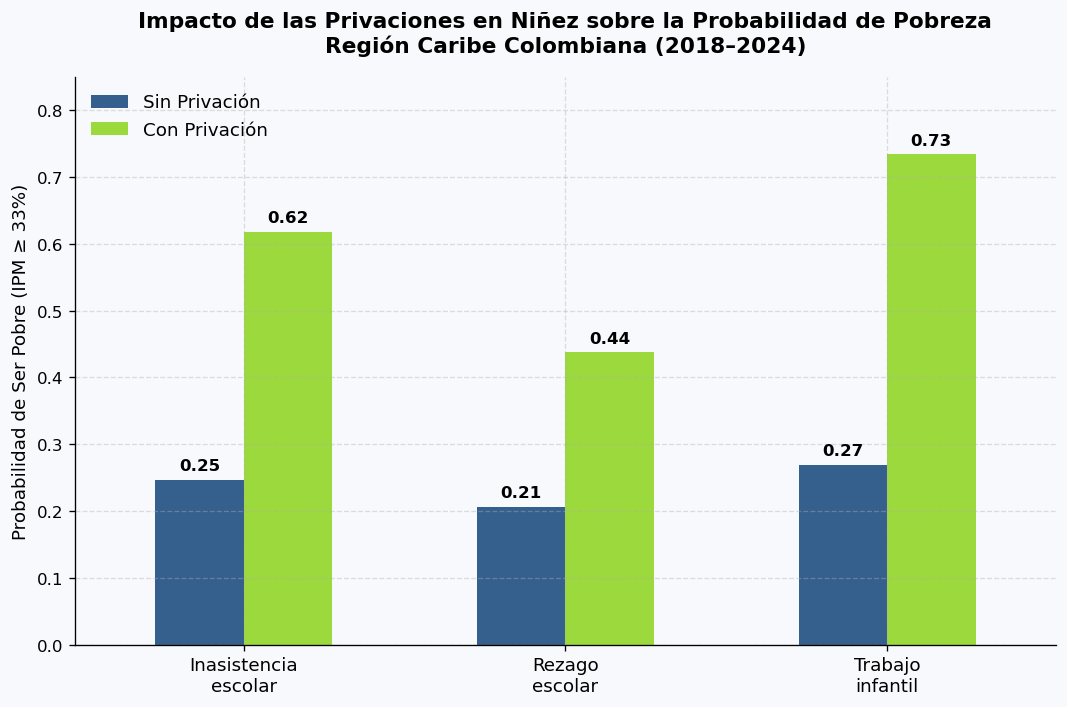

In [19]:
# Comparación del impacto diferencial de tres privaciones en niñez
# sobre la probabilidad de que el hogar sea clasificado como pobre.
vars_ninez = ['inasistencia_escolar', 'rezago_escolar', 'trabajo_infantil']

impacto = []
for var in vars_ninez:
    tabla = pd.crosstab(df[var], df['pobre'], normalize='index')
    impacto.append([tabla.loc[0, 1], tabla.loc[1, 1]])  # [sin privación, con privación]

impacto_df = pd.DataFrame(
    impacto,
    columns=['Sin Privación', 'Con Privación'],
    index=['Inasistencia\nescolar', 'Rezago\nescolar', 'Trabajo\ninfantil']
)

fig, ax = plt.subplots(figsize=(9, 6))

impacto_df.plot(kind='bar', ax=ax,
                color=[VIRIDIS(0.3), VIRIDIS(0.85)],
                width=0.55, edgecolor='none')

ax.set_title('Impacto de las Privaciones en Niñez sobre la Probabilidad de Pobreza\n'
             'Región Caribe Colombiana (2018–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Probabilidad de Ser Pobre (IPM ≥ 33%)', fontsize=11)
ax.set_xlabel('')
ax.set_xticklabels(impacto_df.index, rotation=0, fontsize=11)
ax.legend(frameon=False, fontsize=11, loc='upper left')
ax.set_ylim(0, 0.85)

# Etiquetas de valor sobre cada barra
for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f"{h:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


>
>
> - **Trabajo infantil** es el detonante más severo: un hogar con esta privación tiene más del 70 % de probabilidad de ser pobre, frente a menos del 30 % en hogares sin esta carencia. Que un niño trabaje en lugar de estudiar no solo destruye su capital humano presente, sino que señala una situación de pobreza actual tan aguda que el hogar no puede prescindir de ese ingreso.
> - **Inasistencia escolar** casi triplica la probabilidad de pobreza: de ~25 % a más del 60 %. La desconexión del sistema educativo en la infancia es un predictor robusto de vulnerabilidad sostenida.
> - **Rezago escolar**, incluso sin abandono total, eleva la probabilidad de pobreza por encima del 40 %. No basta con estar en el sistema: la permanencia efectiva y el progreso académico son determinantes.


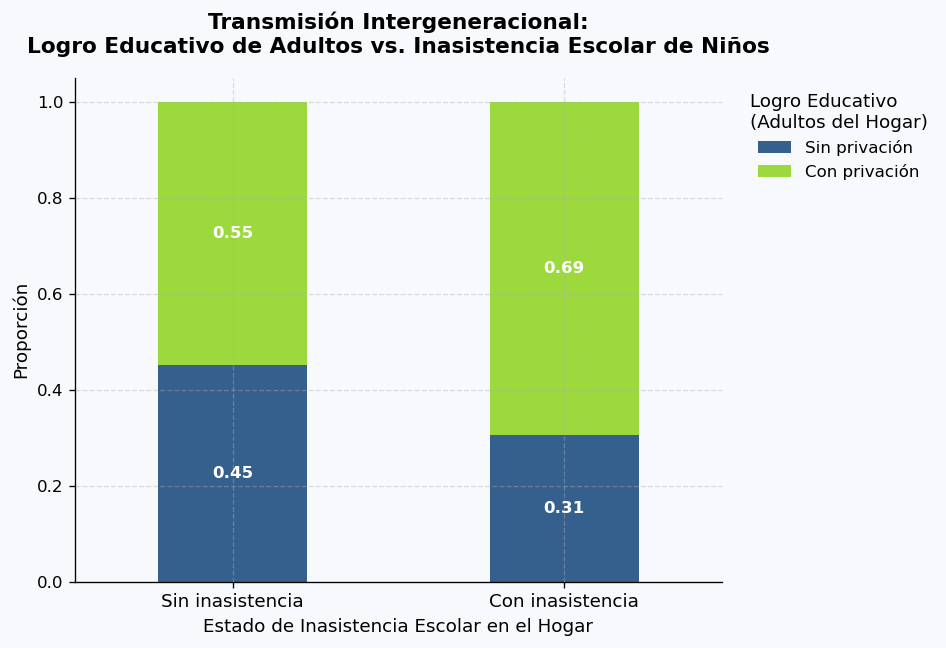

In [20]:
# Vínculo entre privación educativa de adultos e inasistencia escolar de niños
# Este gráfico ilustra el mecanismo de transmisión intergeneracional:
# adultos con bajo logro educativo tienen mayor probabilidad de tener hijos
# que no asisten a la escuela, perpetuando el ciclo.
tabla_transmision = pd.crosstab(
    df['inasistencia_escolar'],
    df['logro_educativo'],
    normalize='index'
)
tabla_transmision.index   = ['Sin inasistencia', 'Con inasistencia']
tabla_transmision.columns = ['Sin privación', 'Con privación']

fig, ax = plt.subplots(figsize=(8, 5.5))

tabla_transmision.plot(
    kind='bar', stacked=True, ax=ax,
    color=[VIRIDIS(0.3), VIRIDIS(0.85)],
    width=0.45, edgecolor='none'
)

ax.set_title('Transmisión Intergeneracional:\nLogro Educativo de Adultos vs. Inasistencia Escolar de Niños',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Proporción', fontsize=11)
ax.set_xlabel('Estado de Inasistencia Escolar en el Hogar', fontsize=11)
ax.set_xticklabels(tabla_transmision.index, rotation=0, fontsize=11)
ax.legend(
    title='Logro Educativo\n(Adultos del Hogar)',  # Agregamos \n para que el título no sea tan largo horizontalmente
    bbox_to_anchor=(1.02, 1),                     # Ancla la leyenda justo afuera a la derecha
    loc='upper left',                             # Alinea la esquina superior izquierda de la leyenda al anclaje
    frameon=False, 
    fontsize=10, 
    title_fontsize=11
)

for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h > 0.07:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + h / 2,
                    f"{h:.2f}", ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


> En hogares donde los adultos presentan privación en logro educativo, la probabilidad de que los niños presenten inasistencia escolar sube al 69 %. En hogares donde los adultos tienen mayor escolaridad, esa probabilidad cae al 55 %. Esta diferencia de 14 puntos porcentuales documenta empíricamente la transmisión intergeneracional: las carencias educativas de los padres limitan el acceso educativo de los hijos, retroalimentando el ciclo.


### 2.2.3 La Educación como Mecanismo de Escape

Si las privaciones educativas alimentan el ciclo de pobreza, la ausencia de esas privaciones debería actuar como su contrapeso. Este análisis examina cuantitativamente el efecto protector de dos indicadores educativos clave — logro educativo y alfabetismo — sobre la condición de pobreza del hogar.


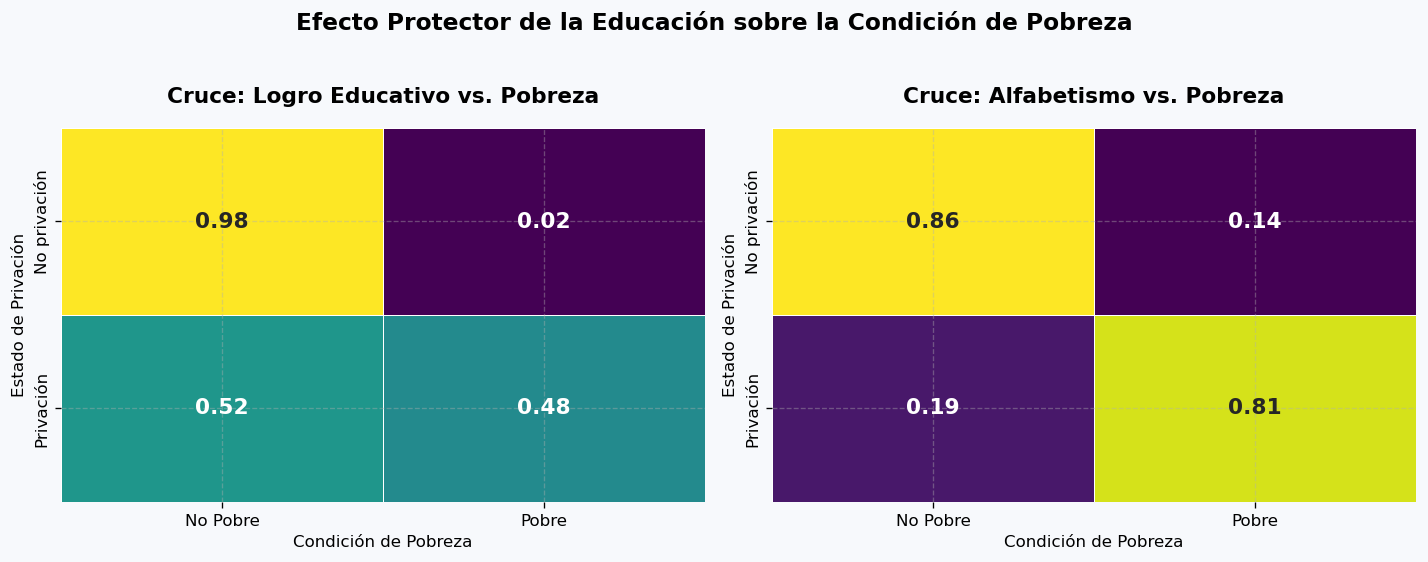

In [21]:
# Heatmaps de cruce — logro educativo y alfabetismo vs. condición de pobreza
# Cada celda muestra la proporción de hogares en esa combinación de estados.
# La asimetría entre filas revela el efecto protector de la educación.
vars_edu = ['logro_educativo', 'alfabetismo']
titulos  = ['Logro Educativo', 'Alfabetismo']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for i, (var, titulo) in enumerate(zip(vars_edu, titulos)):
    tabla = pd.crosstab(df[var], df['pobre'], normalize='index')
    tabla.index   = ['No privación', 'Privación']
    tabla.columns = ['No Pobre', 'Pobre']

    sns.heatmap(
        tabla,
        annot=True, fmt='.2f',
        cmap='viridis',
        cbar=False, ax=axes[i],
        annot_kws={'size': 13, 'weight': 'bold'},
        linewidths=0.5, linecolor='white'
    )
    axes[i].set_title(f"Cruce: {titulo} vs. Pobreza",
                      fontsize=13, fontweight='bold', pad=15)
    axes[i].set_ylabel('Estado de Privación', fontsize=10)
    axes[i].set_xlabel('Condición de Pobreza', fontsize=10)

fig.suptitle('Efecto Protector de la Educación sobre la Condición de Pobreza',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


>
>
> - **Logro educativo:** El 98 % de los hogares sin privación educativa **no son pobres**. Cuando hay privación, la probabilidad de pobreza sube al 48 %. Este es el gradiente más fuerte observado en todo el estudio: la educación básica completa actúa como protección casi total contra la pobreza multidimensional.
> - **Alfabetismo:** Saber leer y escribir reduce la probabilidad de pobreza del 81 % (con privación) al 14 % (sin privación). Es el umbral más básico de inclusión, pero su efecto sobre el bienestar es contundente.
>
> Estos resultados son consistentes con los diagnósticos de la OCDE sobre movilidad social en Colombia y refuerzan la educación como la palanca de política pública con mayor retorno potencial para reducir la pobreza multidimensional en la Región Caribe.


---
## 2.3 Análisis de Composición Regional: Privaciones por Dimensión y Departamento

El análisis variable a variable permite identificar patrones individuales, pero no captura el **peso relativo** de cada dimensión dentro del perfil de pobreza de cada departamento. Esta sección escala el análisis al nivel dimensional, construyendo un índice de privación promedio por dimensión y departamento a partir de promedios ponderados (factor de expansión `fexp`).

Este análisis responde la pregunta: ¿qué dimensiones dominan el perfil de pobreza de cada departamento y existen diferencias estructurales entre territorios?


In [22]:
# Definición de las cinco dimensiones del IPM con sus variables componentes
# Corresponde directamente al diagrama de ponderaciones de Alkire-Foster
# adoptado por el DANE (Angulo, Pardo y Díaz, 2011).
grupos = {
    'Educación':        ['logro_educativo', 'alfabetismo'],
    'Niñez y Juventud': ['rezago_escolar', 'inasistencia_escolar',
                         'atencion_integral', 'trabajo_infantil'],
    'Salud':            ['aseguramiento_salud', 'barreras_acceso_salud'],
    'Trabajo':          ['empleo_formal', 'desempleo_larga_duracion'],
    'Vivienda':         ['acueducto', 'alcantarillado', 'pisos', 'paredes', 'hacinamiento']
}

departamentos_region = [
    'ATLANTICO', 'BOLIVAR', 'CESAR', 'CORDOBA',
    'SUCRE', 'MAGDALENA', 'LA GUAJIRA'
]
df_region = df[df['departamento_nombre'].isin(departamentos_region)]

# Cálculo del promedio ponderado (por fexp) de privación por dimensión y departamento
resultados = {}
for dep, df_dep in df_region.groupby('departamento_nombre'):
    resultados[dep] = {}
    for grupo, variables in grupos.items():
        valores = [np.average(df_dep[var], weights=df_dep['fexp'])
                   for var in variables]
        resultados[dep][grupo] = np.mean(valores) * 100

df_comp = pd.DataFrame(resultados).T

print("Privación promedio ponderada por dimensión y departamento (%):")
print(df_comp.round(1).to_string())


Privación promedio ponderada por dimensión y departamento (%):
            Educación  Niñez y Juventud  Salud  Trabajo  Vivienda
ATLANTICO        19.9              16.3    8.0     43.1       6.4
BOLIVAR          30.2              16.1    5.6     46.9      18.6
CESAR            30.8              18.1    7.2     47.5      11.6
CORDOBA          37.4              15.6    4.7     49.6      20.5
LA GUAJIRA       43.1              21.4   10.3     50.0      34.6
MAGDALENA        34.7              18.6    8.0     47.6      17.8
SUCRE            40.1              16.7    6.3     50.2      16.3


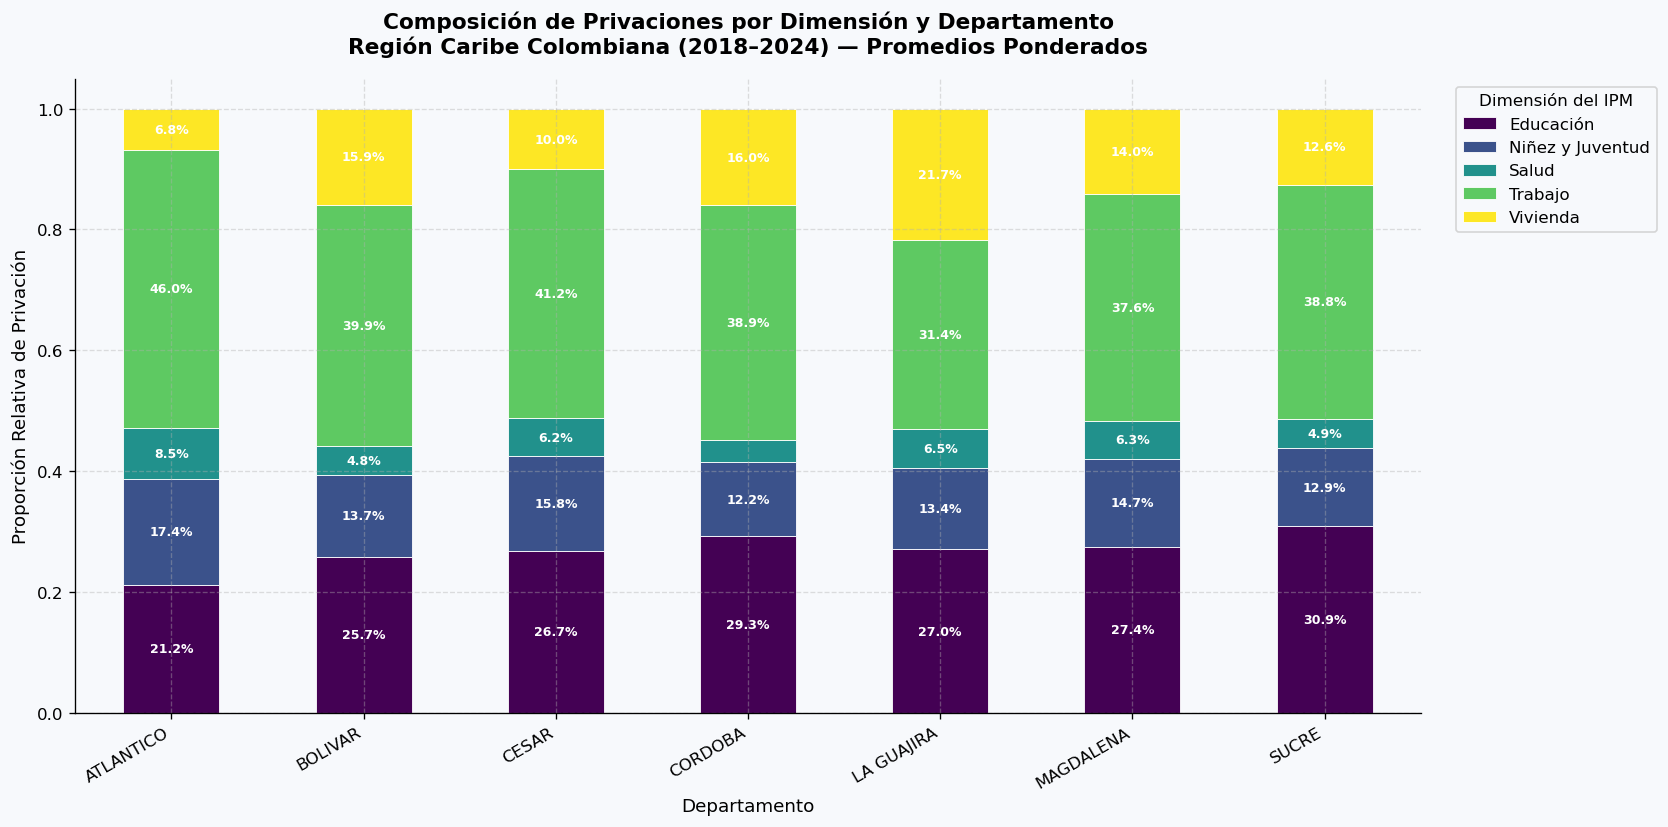

In [23]:
# Composición normalizada de privaciones por departamento
# Se normaliza para mostrar la DISTRIBUCIÓN relativa de privaciones,
# no su magnitud absoluta, permitiendo comparar la estructura de cada departamento.
df_prop = df_comp.div(df_comp.sum(axis=1), axis=0)

# Paleta viridis discreta para las cinco dimensiones
n_dims = len(grupos)
colores_dims = [VIRIDIS(i / (n_dims - 1)) for i in range(n_dims)]

fig, ax = plt.subplots(figsize=(14, 7))

df_prop.plot(
    kind='bar', stacked=True, ax=ax,
    color=colores_dims, edgecolor='white', linewidth=0.5
)

ax.set_title('Composición de Privaciones por Dimensión y Departamento\n'
             'Región Caribe Colombiana (2018–2024) — Promedios Ponderados',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Departamento', fontsize=11)
ax.set_ylabel('Proporción Relativa de Privación', fontsize=11)
ax.set_xticklabels(df_prop.index, rotation=30, ha='right', fontsize=10)
ax.legend(title='Dimensión del IPM', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=10)

for container in ax.containers:
    labels = [f"{v:.1%}" if v > 0.04 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center',
                 fontsize=7.5, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


> La composición de privaciones es **notablemente homogénea** entre departamentos. En todos ellos, **Trabajo y Educación concentran aproximadamente el 60 % de las privaciones totales** — cerca de la mitad corresponde a trabajo (principalmente empleo informal) y alrededor de 2 de cada 5 privaciones son de naturaleza educativa. Esta homogeneidad sugiere que la pobreza multidimensional en la Región Caribe responde a dinámicas estructurales compartidas, no a problemas idiosincráticos de departamentos específicos.


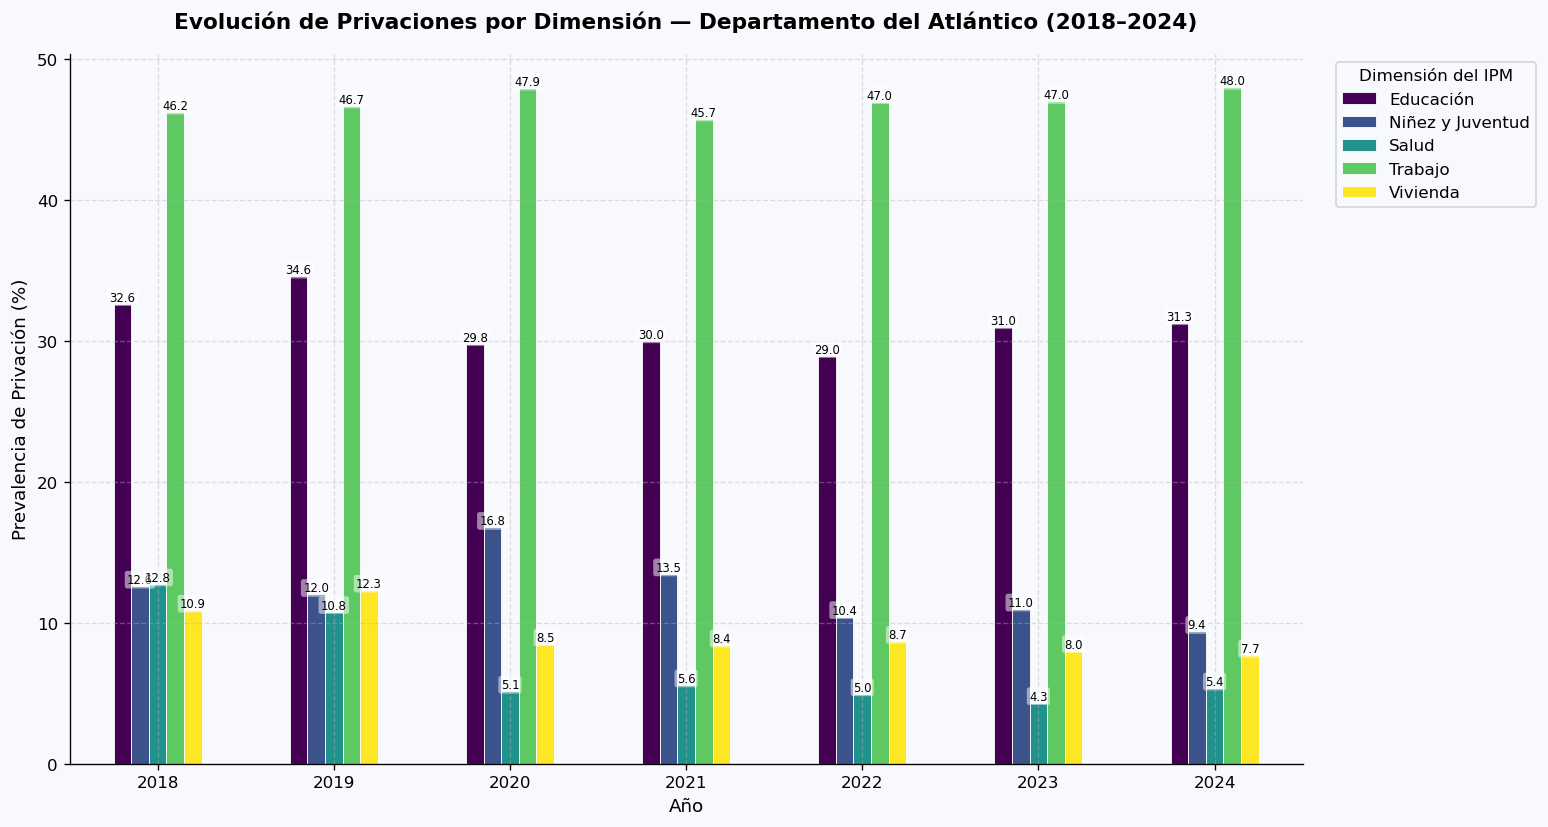

In [24]:
# Desagregación temporal por dimensión — caso Atlántico
# Permite observar cómo evolucionaron las privaciones por dimensión año a año
# en el departamento con mejor desempeño relativo de la región.
# Este análisis puede replicarse para cualquier otro departamento.
df_atlantico = df[df['departamento_nombre'] == 'ATLANTICO']

resultados_atl = {}
for grupo, variables in grupos.items():
    resultados_atl[grupo] = (
        df_atlantico
        .groupby('año')[variables]
        .mean()
        .mean(axis=1) * 100
    )

df_dim_atl = pd.DataFrame(resultados_atl)

# Paleta viridis discreta para dimensiones
colores_dims_atl = [VIRIDIS(i / (n_dims - 1)) for i in range(n_dims)]

fig, ax = plt.subplots(figsize=(13, 7))

df_dim_atl.plot(kind='bar', ax=ax, color=colores_dims_atl,
                edgecolor='white', linewidth=0.5)

ax.set_title('Evolución de Privaciones por Dimensión — Departamento del Atlántico (2018–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Prevalencia de Privación (%)', fontsize=11)
ax.set_xticklabels(df_dim_atl.index, rotation=0, fontsize=10)
ax.legend(title='Dimensión del IPM', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=10)

for container in ax.containers:
    labels = [f"{v:.1f}" if v > 1.0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge',
                 fontsize=7, color='black',
                 bbox=dict(facecolor='white', alpha=0.5,
                           edgecolor='none', boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()



> Se presenta la distribución porcentual de la prevalencia de privación en el departamento del Atlántico, revelando que la dimensión del **Trabajo** se mantiene estructuralmente como la vulnerabilidad más crítica de la región, oscilando con niveles elevados entre el 45.7% (2021) y el 48.0% (2024). Por su parte, la dimensión de **Educación** se consolida como la segunda mayor privación, mostrando una leve tendencia a la baja al pasar del 32.6% en 2018 al 31.3% en 2024, mientras que **Salud** e **Niñez y Juventud** reflejan las contracciones más significativas del periodo, estabilizándose en la pospandemia por debajo del 6% y 10% respectivamente; este comportamiento multidimensional subraya la necesidad de priorizar políticas de formalización laboral y fortalecimiento del capital humano para mitigar de manera sostenible la incidencia del IPM regional.

---
## 2.4 Resumen de Hallazgos y Conexión con el Modelamiento

Este análisis exploratorio identificó los patrones estructurales y relacionales del IPM en la Región Caribe:

| Dimensión | Hallazgo Principal |
|-----------|--------------------|
| **Trabajo** | Privación más extendida (88.8 % en empleo formal). Informalidad estructural y homogénea en todos los departamentos. |
| **Educación** | Segunda dimensión más crítica. El logro educativo (56 %) es el predictor individual más fuerte de pobreza multidimensional. |
| **Salud** | Indicadores favorables. El aseguramiento mejoró durante la pandemia; las barreras de acceso son bajas (3.4 %). |
| **Niñez** | El trabajo infantil es el indicador con mayor asociación con pobreza (+70 %). Documenta transmisión intergeneracional. |
| **Pandemia (2020)** | Choque asimétrico: deterioró empleo e inasistencia escolar, pero mejoró aseguramiento en salud. |

**Implicaciones para el Notebook 3:**

- `logro_educativo` y `empleo_formal` emergen como los features con mayor poder discriminativo sobre la variable objetivo (`pobre` / `ipm`). Su inclusión prioritaria en los modelos es respaldada por los datos.
- La baja multicolinealidad entre variables (documentada en el Notebook 1) valida el uso de todos los indicadores como features independientes sin necesidad de reducción dimensional previa.
- La presencia de heterocedasticidad temporal (mayor volatilidad en 2020–2022) justifica el uso de **regularización Ridge** como estrategia de estabilización en entornos de alta varianza.
- La heterogeneidad entre departamentos sugiere que los modelos deben capturar efectos fijos territoriales — estrategia implementada mediante la arquitectura de datos panel en el Notebook 3.

**Próximo notebook:** `03_Modelamiento.ipynb` — Feature Engineering, Walk-Forward Validation, comparación de modelos y Forecasting del IPM para 2025.
